This lab work focuses on analyzing Titanic Survival Dataset that is already divided into two datasets train and test and performing machine learning tasks to predict whether a passenger survive or not using different algorithms and then checking their accuracy to see which one works best. The key steps involved are:
*   Step 1: Load required libraries
*   Step 2: Load the data
*   Step 3: Data Exploration
*   Step 4: Data Transformation
*   Step 6: Apply machine learning algorithms (e.g., Logistic regression, Decision Tree, Knn )
*   Step 7: Checking Accuracy Scores and Comparing them to see which Algorithm Gives the best result


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.impute import SimpleImputer
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
from sklearn.metrics import confusion_matrix, classification_report

In [ ]:
df_train = pd.read_csv('/content/sample_data/train_KNN.csv')
df_test = pd.read_csv('/content/sample_data/test_KNN.csv')

In [ ]:
df_train.head(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


In [ ]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [ ]:
df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Survived     418 non-null    int64  
 2   Pclass       418 non-null    int64  
 3   Name         418 non-null    object 
 4   Sex          418 non-null    object 
 5   Age          332 non-null    float64
 6   SibSp        418 non-null    int64  
 7   Parch        418 non-null    int64  
 8   Ticket       418 non-null    object 
 9   Fare         417 non-null    float64
 10  Cabin        91 non-null     object 
 11  Embarked     418 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 39.3+ KB


In [ ]:
df_train.isnull().sum()


,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [ ]:
df_train.isnull().sum() / len(df_train) * 100

,0
PassengerId,0.000000
Survived,0.000000
Pclass,0.000000
Name,0.000000
Sex,0.000000
Age,19.865320
SibSp,0.000000
Parch,0.000000
Ticket,0.000000
Fare,0.000000


In [ ]:
((df_train.isnull().sum() / len(df_train)) * 100).sort_values(ascending=False)

,0
Cabin,77.104377
Age,19.865320
Embarked,0.224467
PassengerId,0.000000
Name,0.000000
Pclass,0.000000
Survived,0.000000
Sex,0.000000
Parch,0.000000
SibSp,0.000000


In [ ]:
df_train['Age'].median()

28.0

In [ ]:
df_train['Fare'].median()

14.4542

In [ ]:
((df_test.isnull().sum() / len(df_test)) * 100).sort_values(ascending=False)

,0
Cabin,78.229665
Age,20.574163
Fare,0.239234
PassengerId,0.000000
Name,0.000000
Pclass,0.000000
Survived,0.000000
Sex,0.000000
Parch,0.000000
SibSp,0.000000


In [ ]:
df_test = pd.read_csv('/content/sample_data/test_KNN.csv')
df_test = df_test.drop(columns=['Cabin'])
df_test = df_test.dropna(axis=0, subset=['Embarked'])
median_age_test = df_test['Age'].median()
df_test['Age'] = df_test['Age'].fillna(median_age_test)
if df_test['Fare'].isnull().sum() > 0:
    median_fare_test = df_test['Fare'].median()
    df_test['Fare'] = df_test['Fare'].fillna(median_fare_test)

In [ ]:
df_train = df_train.drop(columns=['Cabin'])
df_train = df_train.dropna(axis=0, subset=['Embarked'])
median_age_train = df_train['Age'].median()
df_train['Age'] = df_train['Age'].fillna(median_age_train)
if df_train['Fare'].isnull().sum() > 0:
    median_fare_train = df_train['Fare'].median()
    df_train['Fare'] = df_train['Fare'].fillna(median_fare_train)
display(df_train.info())

<class 'pandas.core.frame.DataFrame'>
Index: 889 entries, 0 to 890
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  889 non-null    int64  
 1   Survived     889 non-null    int64  
 2   Pclass       889 non-null    int64  
 3   Name         889 non-null    object 
 4   Sex          889 non-null    object 
 5   Age          889 non-null    float64
 6   SibSp        889 non-null    int64  
 7   Parch        889 non-null    int64  
 8   Ticket       889 non-null    object 
 9   Fare         889 non-null    float64
 10  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(4)
memory usage: 83.3+ KB


None

In [ ]:
df_train.drop(["PassengerId","Name","Ticket"], axis = 1, inplace = True)
df_test.drop(["PassengerId","Name","Ticket"], axis = 1, inplace = True)

In [ ]:
df_train_num = df_train.select_dtypes(exclude = "object")
df_train_obj = df_train.select_dtypes(include = "object")

In [ ]:
df_test_num = df_test.select_dtypes(exclude = "object")
df_test_obj = df_test.select_dtypes(include = "object")

In [ ]:
df_train["Survived"] = df_train["Survived"].apply(str)
df_train["Pclass"] = df_train["Pclass"].apply(str)
df_test["Survived"] = df_test["Survived"].apply(str)
df_test["Pclass"] = df_test["Pclass"].apply(str)

In [ ]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 889 entries, 0 to 890
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  889 non-null    object 
 1   Pclass    889 non-null    object 
 2   Sex       889 non-null    object 
 3   Age       889 non-null    float64
 4   SibSp     889 non-null    int64  
 5   Parch     889 non-null    int64  
 6   Fare      889 non-null    float64
 7   Embarked  889 non-null    object 
dtypes: float64(2), int64(2), object(4)
memory usage: 62.5+ KB


In [ ]:
df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  418 non-null    object 
 1   Pclass    418 non-null    object 
 2   Sex       418 non-null    object 
 3   Age       418 non-null    float64
 4   SibSp     418 non-null    int64  
 5   Parch     418 non-null    int64  
 6   Fare      418 non-null    float64
 7   Embarked  418 non-null    object 
dtypes: float64(2), int64(2), object(4)
memory usage: 26.3+ KB


In [ ]:
df_train_num = df_train.select_dtypes(exclude = "object")
df_train_obj = df_train.select_dtypes(include = "object")

In [ ]:
df_test_num = df_test.select_dtypes(exclude = "object")
df_test_obj = df_test.select_dtypes(include = "object")

In [ ]:
df_train_num.columns

Index(['Age', 'SibSp', 'Parch', 'Fare'], dtype='object')

In [ ]:
Final_train_df = pd.concat([df_train_num, df_train_obj], axis=1)
Final_train_df.head()

,Age,SibSp,Parch,Fare,Survived,Pclass,Sex,Embarked
0,22.0,1,0,7.2500,0,3,male,S
1,38.0,1,0,71.2833,1,1,female,C
2,26.0,0,0,7.9250,1,3,female,S
3,35.0,1,0,53.1000,1,1,female,S
4,35.0,0,0,8.0500,0,3,male,S


In [ ]:
Final_test_df = pd.concat([df_test_num,df_test_obj], axis=1)
Final_test_df.head()

,Age,SibSp,Parch,Fare,Survived,Pclass,Sex,Embarked
0,34.5,0,0,7.8292,0,3,male,Q
1,47.0,1,0,7.0000,1,3,female,S
2,62.0,0,0,9.6875,0,2,male,Q
3,27.0,0,0,8.6625,0,3,male,S
4,22.0,1,1,12.2875,1,3,female,S


In [ ]:
X_train = Final_train_df.drop("Survived", axis =1)
y_train = Final_train_df["Survived"]
X_test = Final_test_df.drop("Survived", axis =1)
y_test = Final_test_df["Survived"]

In [ ]:
scaler = StandardScaler()

categorical_cols = X_train.select_dtypes(include='object').columns

X_train = pd.get_dummies(X_train, columns=categorical_cols, drop_first=True)

X_test_temp_encoded = pd.get_dummies(X_test, columns=categorical_cols, drop_first=True)
train_cols = X_train.columns
X_test_aligned = X_test_temp_encoded.reindex(columns=train_cols, fill_value=0)
scaler.fit(X_train)

StandardScaler()

In [ ]:
scaled_X_train = scaler.transform(X_train)
scaled_X_test = scaler.transform(X_test_aligned)

In [ ]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(scaled_X_train, y_train)

KNeighborsClassifier()

In [ ]:
y_pred = knn.predict(scaled_X_test)

In [ ]:
accuracy_score(y_test, y_pred)

0.8133971291866029

In [ ]:
Performance_Metric = []
for k in range(1,30):
    knn_k = KNeighborsClassifier(n_neighbors=k)
    knn_k.fit(scaled_X_train, y_train)
    y_pred_k = knn_k.predict(scaled_X_test)

    accuracy_k = 1 - accuracy_score(y_test, y_pred_k)
    Performance_Metric.append(accuracy_k)

In [ ]:
Performance_Metric

[0.26555023923444976,
 0.19617224880382778,
 0.22248803827751196,
 0.20334928229665072,
 0.1866028708133971,
 0.1291866028708134,
 0.14832535885167464,
 0.1267942583732058,
 0.14593301435406703,
 0.12440191387559807,
 0.11961722488038273,
 0.11722488038277512,
 0.11483253588516751,
 0.11483253588516751,
 0.1291866028708134,
 0.12200956937799046,
 0.11722488038277512,
 0.11004784688995217,
 0.11483253588516751,
 0.12440191387559807,
 0.13875598086124397,
 0.12440191387559807,
 0.13157894736842102,
 0.1291866028708134,
 0.13636363636363635,
 0.13157894736842102,
 0.13157894736842102,
 0.13397129186602874,
 0.12440191387559807]

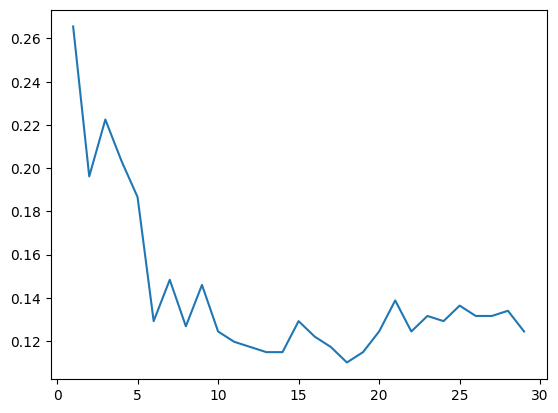

In [ ]:
plt.plot(range(1,30), Performance_Metric)

Logistic Regression and its scores

In [ ]:
from sklearn.linear_model import LogisticRegression

logreg = LogisticRegression(solver='liblinear', random_state=0)

logreg.fit(scaled_X_train, y_train)

LogisticRegression(random_state=0, solver='liblinear')

In [ ]:
y_pred_test = logreg.predict(scaled_X_test)

y_pred_test

array(['0', '0', '0', '0', '1', '0', '1', '0', '1', '0', '0', '0', '1',
       '0', '1', '1', '0', '0', '1', '1', '0', '0', '1', '1', '1', '0',
       '1', '0', '0', '0', '0', '0', '0', '0', '0', '0', '1', '1', '0',
       '0', '0', '0', '0', '1', '1', '0', '0', '0', '1', '0', '0', '0',
       '1', '1', '0', '0', '0', '0', '0', '1', '0', '0', '0', '1', '1',
       '1', '1', '0', '1', '1', '1', '0', '1', '1', '1', '1', '0', '1',
       '0', '1', '0', '0', '0', '0', '0', '0', '1', '1', '1', '0', '1',
       '0', '1', '0', '1', '0', '1', '0', '1', '0', '1', '0', '0', '0',
       '1', '0', '0', '0', '0', '0', '0', '1', '1', '1', '1', '0', '0',
       '1', '1', '1', '1', '0', '1', '0', '0', '1', '0', '1', '0', '0',
       '0', '0', '1', '0', '0', '0', '0', '0', '1', '0', '0', '1', '0',
       '0', '0', '0', '0', '0', '0', '0', '1', '0', '0', '0', '0', '0',
       '1', '1', '0', '1', '1', '0', '1', '0', '0', '1', '0', '0', '1',
       '1', '0', '0', '0', '0', '0', '1', '1', '0', '1', '1', '0

In [ ]:
logreg.predict_proba(scaled_X_test)[:,0]

array([0.89423089, 0.6510313 , 0.87529549, 0.90275742, 0.44033695,
       0.85036899, 0.32983935, 0.79032147, 0.22749422, 0.93018289,
       0.90292689, 0.69462605, 0.07260419, 0.93315279, 0.16926686,
       0.12436037, 0.71618279, 0.82709196, 0.46715475, 0.44863096,
       0.72084109, 0.839636  , 0.07027998, 0.36395785, 0.09725246,
       0.96746418, 0.03928497, 0.83501803, 0.65074   , 0.91534414,
       0.89537213, 0.81265799, 0.56078359, 0.50281341, 0.50294406,
       0.81321594, 0.39056231, 0.33797372, 0.89574849, 0.89165059,
       0.91036174, 0.5262948 , 0.94032224, 0.17349901, 0.16186853,
       0.89611853, 0.58273364, 0.86443201, 0.13084312, 0.51399175,
       0.55505813, 0.63524752, 0.22347395, 0.1185221 , 0.63492872,
       0.92428697, 0.92630736, 0.89618302, 0.92570883, 0.03676318,
       0.8645691 , 0.76633486, 0.8689581 , 0.26692522, 0.34327582,
       0.15523607, 0.23844372, 0.69384392, 0.4526335 , 0.22336226,
       0.28189914, 0.88125123, 0.40869744, 0.42994397, 0.04010

In [ ]:
logreg.predict_proba(scaled_X_test)[:,1]

array([0.10576911, 0.3489687 , 0.12470451, 0.09724258, 0.55966305,
       0.14963101, 0.67016065, 0.20967853, 0.77250578, 0.06981711,
       0.09707311, 0.30537395, 0.92739581, 0.06684721, 0.83073314,
       0.87563963, 0.28381721, 0.17290804, 0.53284525, 0.55136904,
       0.27915891, 0.160364  , 0.92972002, 0.63604215, 0.90274754,
       0.03253582, 0.96071503, 0.16498197, 0.34926   , 0.08465586,
       0.10462787, 0.18734201, 0.43921641, 0.49718659, 0.49705594,
       0.18678406, 0.60943769, 0.66202628, 0.10425151, 0.10834941,
       0.08963826, 0.4737052 , 0.05967776, 0.82650099, 0.83813147,
       0.10388147, 0.41726636, 0.13556799, 0.86915688, 0.48600825,
       0.44494187, 0.36475248, 0.77652605, 0.8814779 , 0.36507128,
       0.07571303, 0.07369264, 0.10381698, 0.07429117, 0.96323682,
       0.1354309 , 0.23366514, 0.1310419 , 0.73307478, 0.65672418,
       0.84476393, 0.76155628, 0.30615608, 0.5473665 , 0.77663774,
       0.71810086, 0.11874877, 0.59130256, 0.57005603, 0.95989

In [ ]:
print('Model accuracy score: {0:0.4f}'. format(accuracy_score(y_test, y_pred_test)))

Model accuracy score: 0.9474


In [ ]:
y_pred_train = logreg.predict(scaled_X_train)

y_pred_train

array(['0', '1', '1', '1', '0', '0', '0', '0', '1', '1', '1', '1', '0',
       '0', '1', '1', '0', '0', '1', '1', '0', '0', '1', '0', '1', '0',
       '0', '0', '1', '0', '0', '1', '1', '0', '1', '0', '0', '0', '1',
       '1', '0', '1', '0', '1', '1', '0', '0', '1', '0', '1', '0', '0',
       '1', '1', '0', '0', '1', '0', '1', '0', '0', '0', '0', '1', '0',
       '1', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0',
       '1', '0', '0', '1', '0', '1', '0', '0', '0', '1', '0', '0', '0',
       '0', '0', '0', '0', '0', '1', '1', '0', '1', '0', '1', '0', '0',
       '0', '1', '0', '0', '1', '0', '1', '0', '1', '1', '0', '0', '0',
       '1', '1', '0', '0', '0', '1', '0', '0', '0', '0', '1', '0', '0',
       '0', '0', '1', '0', '0', '1', '0', '0', '1', '1', '1', '1', '0',
       '0', '0', '0', '1', '0', '0', '0', '1', '0', '0', '0', '0', '1',
       '0', '0', '0', '0', '1', '0', '0', '0', '0', '1', '0', '0', '0',
       '0', '0', '1', '0', '0', '0', '0', '1', '0', '0', '0', '0

In [ ]:
print('Training-set accuracy score: {0:0.4f}'. format(accuracy_score(y_train, y_pred_train)))

Training-set accuracy score: 0.8043


In [ ]:
print('Training set score: {:.4f}'.format(logreg.score(scaled_X_train, y_train)))

print('Test set score: {:.4f}'.format(logreg.score(scaled_X_test, y_test)))

Training set score: 0.8043
Test set score: 0.9474


In [ ]:
cm = confusion_matrix(y_test, y_pred_test)

print('Confusion matrix\n\n', cm)

print('\nTrue Positives(TP) = ', cm[0,0])

print('\nTrue Negatives(TN) = ', cm[1,1])

print('\nFalse Positives(FP) = ', cm[0,1])

print('\nFalse Negatives(FN) = ', cm[1,0])

Confusion matrix

 [[254  12]
 [ 10 142]]

True Positives(TP) =  254

True Negatives(TN) =  142

False Positives(FP) =  12

False Negatives(FN) =  10


<Axes: >

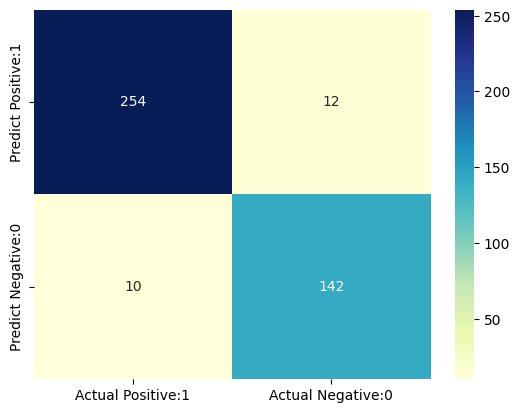

In [ ]:
cm_matrix = pd.DataFrame(data=cm, columns=['Actual Positive:1', 'Actual Negative:0'],
                                 index=['Predict Positive:1', 'Predict Negative:0'])

sns.heatmap(cm_matrix, annot=True, fmt='d', cmap='YlGnBu')

In [ ]:
print(classification_report(y_test, y_pred_test))

              precision    recall  f1-score   support

           0       0.96      0.95      0.96       266
           1       0.92      0.93      0.93       152

    accuracy                           0.95       418
   macro avg       0.94      0.94      0.94       418
weighted avg       0.95      0.95      0.95       418



Decision Tree and its Scores

In [ ]:
tree = DecisionTreeClassifier()
tree.fit(scaled_X_train, y_train)
tree.score(scaled_X_test, y_test)

0.7727272727272727

In [ ]:
clf = confusion_matrix(y_test,tree.predict(scaled_X_test))
print(clf)

[[207  59]
 [ 36 116]]


<Axes: >

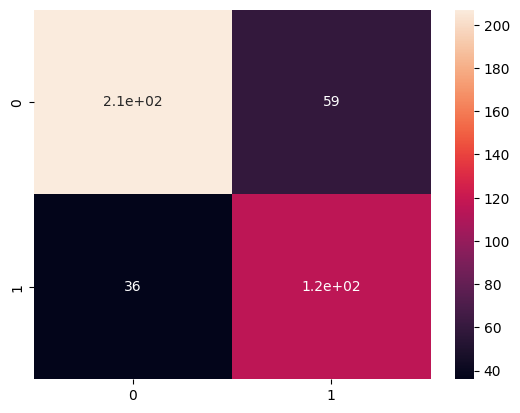

In [ ]:
sns.heatmap(clf,annot=True)

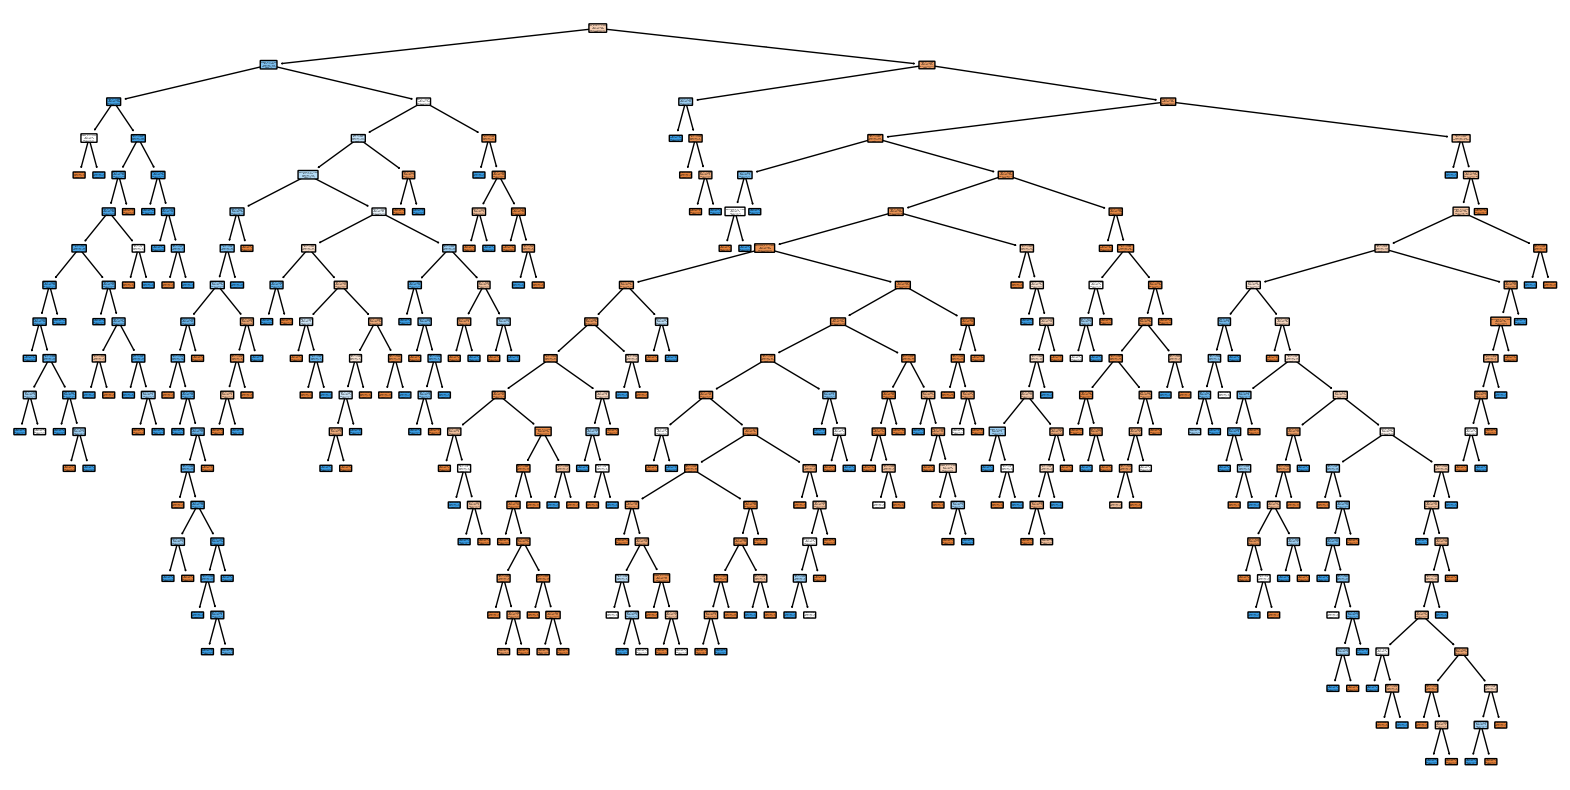

In [ ]:
plt.figure(figsize=(20,10))
plot_tree(tree, filled=True, feature_names=X_train.columns.tolist(), class_names=['0', '1'], rounded=True);
plt.show()

In [ ]:
min_error_rate_knn = min(Performance_Metric)
best_knn_accuracy = 1 - min_error_rate_knn

logistic_regression_accuracy = logreg.score(scaled_X_test, y_test)

decision_tree_accuracy = tree.score(scaled_X_test, y_test)

print(f"Best KNN Accuracy: {best_knn_accuracy:.4f}")
print(f"Logistic Regression Accuracy: {logistic_regression_accuracy:.4f}")
print(f"Decision Tree Accuracy: {decision_tree_accuracy:.4f}")

Best KNN Accuracy: 0.8900
Logistic Regression Accuracy: 0.9474
Decision Tree Accuracy: 0.7727


In [ ]:
accuracy_scores = {
    "KNN": best_knn_accuracy,
    "Logistic Regression": logistic_regression_accuracy,
    "Decision Tree": decision_tree_accuracy}

highest_accuracy_algorithm = max(accuracy_scores, key=accuracy_scores.get)
highest_accuracy_score = accuracy_scores[highest_accuracy_algorithm]

print(f"The algorithm with the highest accuracy is: {highest_accuracy_algorithm} (Accuracy: {highest_accuracy_score:.4f})")

The algorithm with the highest accuracy is: Logistic Regression (Accuracy: 0.9474)
